In [ ]:
# First, lets visualize the dataset

import pandas as pd

# File paths
en_file = "europarl-v7.es-en.en"
es_file = "europarl-v7.es-en.es"

# Load lines from each file
with open(en_file, encoding="utf-8") as f_en, open(es_file, encoding="utf-8") as f_es:
    en_sentences = f_en.readlines()
    es_sentences = f_es.readlines()

# Create DataFrame
df = pd.DataFrame({
    "en": [line.strip() for line in en_sentences],
    "es": [line.strip() for line in es_sentences]
})

df

,en,es
0,Resumption of the session,Reanudación del período de sesiones
1,I declare resumed the session of the European ...,Declaro reanudado el período de sesiones del P...
2,"Although, as you will have seen, the dreaded '...","Como todos han podido comprobar, el gran ""efec..."
3,You have requested a debate on this subject in...,Sus Señorías han solicitado un debate sobre el...
4,"In the meantime, I should like to observe a mi...","A la espera de que se produzca, de acuerdo con..."
...,...,...
1965729,"I would also like, although they are absent, t...","Incluso me permitiría, aunque estén ausentes, ..."
1965730,I am not going to re-open the 'Millennium or n...,"No voy a abrir otra vez el debate sobre ""milen..."
1965731,Adjournment of the session,Interrupción del periodo de sesiones
1965732,I declare the session of the European Parliame...,Declaro interrumpido el período de sesiones de...


In [5]:
# Most common words (with and without stopwords)

import pandas as pd
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopword lists
nltk.download('stopwords')

# Tokenizer
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

# Stopword sets
stopwords_en = set(stopwords.words('english'))
stopwords_es = set(stopwords.words('spanish'))

# Word counters
en_all = Counter()
en_filtered = Counter()
es_all = Counter()
es_filtered = Counter()

# Process English
for sentence in df['en']:
    tokens = tokenize(sentence)
    en_all.update(tokens)
    en_filtered.update([t for t in tokens if t not in stopwords_en])

# Process Spanish
for sentence in df['es']:
    tokens = tokenize(sentence)
    es_all.update(tokens)
    es_filtered.update([t for t in tokens if t not in stopwords_es])

# Show results
print()
print("Top English words (with stopwords):")
print(en_all.most_common(10))

print("\n🧹 Top English words (without stopwords):")
print(en_filtered.most_common(10))

print("\nTop Spanish words (with stopwords):")
print(es_all.most_common(10))

print("\n🧹 Top Spanish words (without stopwords):")
print(es_filtered.most_common(10))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/desjardins/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Top English words (with stopwords):
[('the', 3770151), ('of', 1786647), ('to', 1659461), ('and', 1417421), ('in', 1180227), ('that', 902203), ('a', 835697), ('is', 831430), ('for', 576552), ('we', 568557)]

🧹 Top English words (without stopwords):
[('european', 292951), ('mr', 193096), ('commission', 175823), ('would', 165794), ('also', 163705), ('president', 152998), ('must', 142884), ('union', 129432), ('parliament', 123669), ('states', 117544)]

Top Spanish words (with stopwords):
[('de', 3568662), ('la', 2434546), ('que', 1892919), ('en', 1548996), ('el', 1389982), ('y', 1333608), ('a', 1143984), ('los', 1071846), ('las', 733536), ('del', 595480)]

🧹 Top Spanish words (without stopwords):
[('comisión', 222246), ('europea', 162188), ('señor', 161916), ('unión', 141164), ('presidente', 127996), ('parlamento', 126239), ('si', 111508), ('informe', 106991), ('consejo', 105071), ('europeo', 101665)]


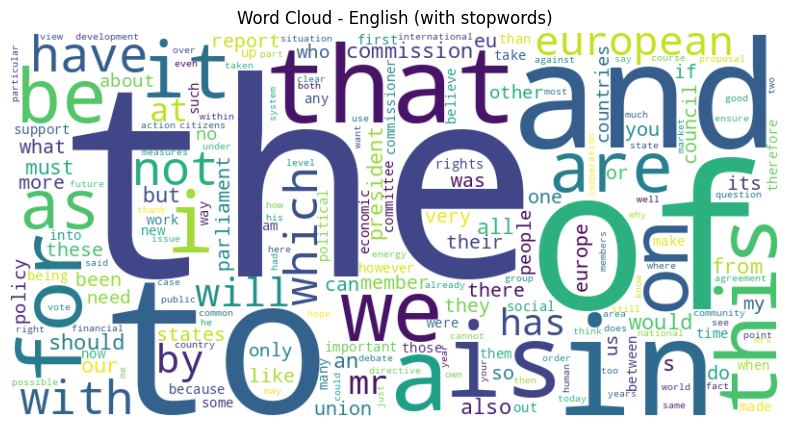

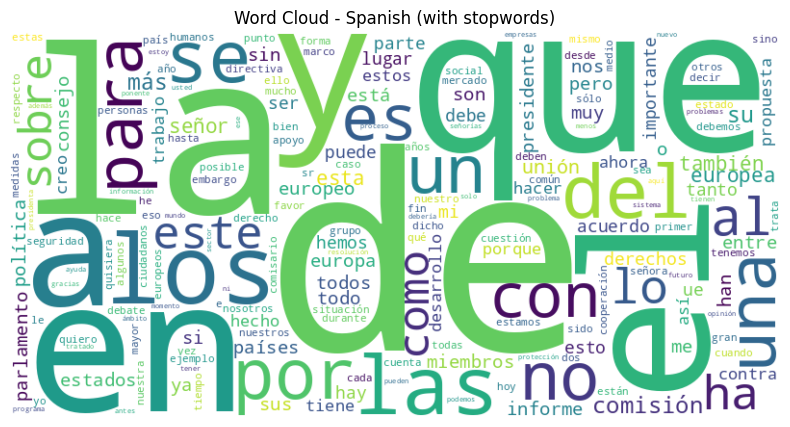

In [ ]:
# Word Clouds (with stopwords)

import pandas as pd
from collections import Counter
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Tokenizer
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

# Join all text per language
all_en_text = " ".join(df['en'].dropna().tolist())
all_es_text = " ".join(df['es'].dropna().tolist())

# Tokenize
tokens_en = tokenize(all_en_text)
tokens_es = tokenize(all_es_text)

# Count frequencies
counter_en = Counter(tokens_en)
counter_es = Counter(tokens_es)

# Create WordCloud objects
wordcloud_en = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(counter_en)
wordcloud_es = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(counter_es)

# Plot English
plt.figure(figsize=(10, 5))
plt.title("Word Cloud - English (with stopwords)")
plt.imshow(wordcloud_en, interpolation='bilinear')
plt.axis("off")
plt.show()

# Plot Spanish
plt.figure(figsize=(10, 5))
plt.title("Word Cloud - Spanish (with stopwords)")
plt.imshow(wordcloud_es, interpolation='bilinear')
plt.axis("off")
plt.show()

In [9]:
# TF-IDF Bigrams

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

# Download stopwords
nltk.download('stopwords')

# Get stopwords
stopwords_en = 'english'  # built-in
stopwords_es = stopwords.words('spanish')  # list

# TF-IDF Vectorizer settings
vectorizer_en = TfidfVectorizer(ngram_range=(2, 2), max_features=100, stop_words=stopwords_en)
vectorizer_es = TfidfVectorizer(ngram_range=(2, 2), max_features=100, stop_words=stopwords_es)

# Fit and transform
X_en = vectorizer_en.fit_transform(df['en'].dropna())
X_es = vectorizer_es.fit_transform(df['es'].dropna())

# Extract top bigrams
def get_top_bigrams(vectorizer, X, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = X.sum(axis=0).A1
    return sorted(zip(tfidf_scores, feature_names), reverse=True)[:top_n]

# Display top bigrams
print("Top English TF-IDF Bigrams:")
for score, bigram in get_top_bigrams(vectorizer_en, X_en):
    print(f"{bigram}: {score:.2f}")

print("\nTop Spanish TF-IDF Bigrams:")
for score, bigram in get_top_bigrams(vectorizer_es, X_es):
    print(f"{bigram}: {score:.2f}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/desjardins/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top English TF-IDF Bigrams:
european union: 71909.69
member states: 69175.79
mr president: 64850.17
european parliament: 33295.53
human rights: 23397.17
madam president: 18826.03
ladies gentlemen: 16197.91
united states: 10643.27
member state: 10103.47
european commission: 9712.19

Top Spanish TF-IDF Bigrams:
unión europea: 78361.15
señor presidente: 68300.20
parlamento europeo: 35458.31
derechos humanos: 23171.00
señora presidenta: 20663.40
primer lugar: 16261.63
medio ambiente: 14633.48
señor comisario: 11886.26
mismo tiempo: 10819.55
comisión europea: 10360.46


In [10]:
# TF-IDF Trigrams

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

# Download stopwords
nltk.download('stopwords')

# Get stopwords
stopwords_en = 'english'  # built-in
stopwords_es = stopwords.words('spanish')  # list

# TF-IDF Vectorizer settings for trigrams
vectorizer_en = TfidfVectorizer(ngram_range=(3, 3), max_features=100, stop_words=stopwords_en)
vectorizer_es = TfidfVectorizer(ngram_range=(3, 3), max_features=100, stop_words=stopwords_es)

# Fit and transform
X_en = vectorizer_en.fit_transform(df['en'].dropna())
X_es = vectorizer_es.fit_transform(df['es'].dropna())

# Extract top trigrams
def get_top_trigrams(vectorizer, X, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = X.sum(axis=0).A1
    return sorted(zip(tfidf_scores, feature_names), reverse=True)[:top_n]

# Display top trigrams
print("Top English TF-IDF Trigrams:")
for score, trigram in get_top_trigrams(vectorizer_en, X_en):
    print(f"{trigram}: {score:.2f}")

print("\nTop Spanish TF-IDF Trigrams:")
for score, trigram in get_top_trigrams(vectorizer_es, X_es):
    print(f"{trigram}: {score:.2f}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/desjardins/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top English TF-IDF Trigrams:
president ladies gentlemen: 8210.40
mr president ladies: 6887.78
mr president like: 6441.06
mr president commissioner: 6176.42
new member states: 4279.92
president office council: 4242.02
eu member states: 4052.56
small medium sized: 3696.59
commissioner ladies gentlemen: 3217.75
common agricultural policy: 2739.34

Top Spanish TF-IDF Trigrams:
señor presidente señorías: 7973.39
señor presidente señor: 4878.28
votado favor informe: 4053.93
pequeñas medianas empresas: 3795.56
presidente ejercicio consejo: 3486.93
debate queda cerrado: 3290.50
señor presidente quiero: 3268.20
miembros unión europea: 3199.04
presidente señor comisario: 3132.68
quiero dar gracias: 3066.78


In [11]:
# Unique words

import pandas as pd
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download necessary NLTK data (if not already)
nltk.download('punkt')

def count_unique_words(text_series):
    all_words = []
    for text in text_series.dropna():
        tokens = word_tokenize(text.lower())  # lowercase and tokenize
        all_words.extend(tokens)
    unique_words = set(all_words)
    return len(unique_words)

# Assuming df['en'] and df['es'] exist
unique_en = count_unique_words(df['en'])
unique_es = count_unique_words(df['es'])

print(f"Unique words in English corpus: {unique_en}")
print(f"Unique words in Spanish corpus: {unique_es}")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/desjardins/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Unique words in English corpus: 135400
Unique words in Spanish corpus: 195206


In [ ]:
# Token count

import pandas as pd
import matplotlib.pyplot as plt
import nltk
import seaborn as sns

nltk.download('punkt')

# Token count
df['en_token_count'] = df['en'].dropna().apply(lambda x: len(nltk.word_tokenize(x)))
df['es_token_count'] = df['es'].dropna().apply(lambda x: len(nltk.word_tokenize(x)))

# Plot token count distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(df['en_token_count'], label="English", shade=True)
sns.kdeplot(df['es_token_count'], label="Spanish", shade=True)
plt.title("Sentence Token Count Distribution")
plt.xlabel("Token Count")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Corpus-Level Lexical Diversity

import pandas as pd
import nltk
from nltk.tokenize import word_tokenize

# Download tokenizer models if needed
nltk.download('punkt')

def lexical_diversity(text_series):
    tokens = []
    for text in text_series.dropna():
        tokens.extend(word_tokenize(text.lower()))
    types = set(tokens)
    if len(tokens) == 0:
        return 0
    return len(types) / len(tokens)

# Calculate lexical diversity for English and Spanish
lex_div_en = lexical_diversity(df['en'])
lex_div_es = lexical_diversity(df['es'])

print(f"English corpus lexical diversity (TTR): {lex_div_en:.4f}")
print(f"Spanish corpus lexical diversity (TTR): {lex_div_es:.4f}")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/desjardins/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


English corpus lexical diversity (TTR): 0.0025
Spanish corpus lexical diversity (TTR): 0.0034


In [ ]:
# Part of speech (POS) tag distribution

import pandas as pd
import nltk
import spacy
from collections import Counter
from nltk import word_tokenize, pos_tag

# Load Spanish spaCy model
nlp_es = spacy.load("es_core_news_sm")

# Download NLTK models
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# POS Tag English
def pos_distribution_en(text_series):
    pos_counts = Counter()
    for text in text_series.dropna():
        tokens = word_tokenize(text)
        tags = pos_tag(tokens)
        pos_counts.update(tag for _, tag in tags)
    return pos_counts

# POS Tag Spanish
def pos_distribution_es(text_series):
    pos_counts = Counter()
    for doc in nlp_es.pipe(text_series.dropna().tolist(), disable=["ner"]):
        pos_counts.update([token.pos_ for token in doc])
    return pos_counts

# Compute POS distributions
pos_en = pos_distribution_en(df["en"])
pos_es = pos_distribution_es(df["es"])

# Display results
print("🔠 English POS Tag Distribution (Penn Treebank tags):")
for tag, count in pos_en.most_common():
    print(f"{tag}: {count}")

print("\n🔤 Spanish POS Tag Distribution (Universal POS tags):")
for tag, count in pos_es.most_common():
    print(f"{tag}: {count}")

OSError: [E050] Can't find model 'es_core_news_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

In [ ]:
# LDA model discovers the top 3 topics per sentiment and visualizes the top 10 word weights for each topic

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
import io
from contextlib import redirect_stdout, redirect_stderr

# Ensure NLTK resources are available silently
def safe_nltk_download(resource):
    try:
        nltk.data.find(resource)
    except LookupError:
        f = io.StringIO()
        with redirect_stdout(f), redirect_stderr(f):
            nltk.download(resource.split('/')[-1])

safe_nltk_download('tokenizers/punkt')
safe_nltk_download('corpora/stopwords')

from nltk.corpus import stopwords

# Use NLTK stopwords
stop_words_en = stopwords.words('english')
stop_words_es = stopwords.words('spanish')

# Reusable plot function
def plot_top_words_per_topic(lda_model, feature_names, n_top_words=10, label=None, color=None):
    n_topics = lda_model.n_components
    fig, axes = plt.subplots(n_topics, 1, figsize=(10, n_topics * 3), sharex=False)

    if n_topics == 1:
        axes = [axes]

    for topic_idx, topic in enumerate(lda_model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = topic[top_indices]

        ax = axes[topic_idx]
        ax.bar(top_words, top_weights, color=color)
        ax.set_title(f'Topic #{topic_idx + 1}' + (f' - Language: {label}' if label else ''))
        ax.set_ylabel('Weight')
        ax.set_xlabel('Words')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylim(0, max(top_weights) * 1.1)

    plt.tight_layout()
    plt.show()

# Parameters
n_topics = 3
n_top_words = 10

# Store results
results = {}

# Run LDA for English
texts_en = df['en'].dropna().astype(str)
vectorizer_en = CountVectorizer(stop_words=stop_words_en, max_features=1000)
dtm_en = vectorizer_en.fit_transform(texts_en)
lda_en = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_en.fit(dtm_en)

print("\nTopics for English corpus:")
plot_top_words_per_topic(lda_en, vectorizer_en.get_feature_names_out(), n_top_words=n_top_words, label="English", color='skyblue')
results['en'] = lda_en

# Run LDA for Spanish
texts_es = df['es'].dropna().astype(str)
vectorizer_es = CountVectorizer(stop_words=stop_words_es, max_features=1000)
dtm_es = vectorizer_es.fit_transform(texts_es)
lda_es = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_es.fit(dtm_es)

print("\nTopics for Spanish corpus:")
plot_top_words_per_topic(lda_es, vectorizer_es.get_feature_names_out(), n_top_words=n_top_words, label="Spanish", color='salmon')
results['es'] = lda_es

In [ ]:
# Named Entitiy Recognition

import spacy
from collections import Counter
import matplotlib.pyplot as plt

# Load spaCy models
nlp_en = spacy.load("en_core_web_sm")
nlp_es = spacy.load("es_core_news_sm")

# NER functions
def get_entity_counts(docs, label="en"):
    counter = Counter()
    for doc in docs:
        counter.update([ent.label_ for ent in doc.ents])
    return counter

# Run NER
docs_en = list(nlp_en.pipe(df['en'].dropna().astype(str).tolist(), disable=["tagger", "parser"]))
docs_es = list(nlp_es.pipe(df['es'].dropna().astype(str).tolist(), disable=["tagger", "parser"]))

ner_counts_en = get_entity_counts(docs_en, "en")
ner_counts_es = get_entity_counts(docs_es, "es")

# Plot
def plot_ner(counts, title):
    plt.figure(figsize=(8, 4))
    labels, values = zip(*counts.items())
    plt.bar(labels, values)
    plt.title(title)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_ner(ner_counts_en, "English Named Entity Distribution")
plot_ner(ner_counts_es, "Spanish Named Entity Distribution")

In [ ]:
# Detect english words in spanish and vice versa

import nltk
from nltk.corpus import words, stopwords

# Download word list
nltk.download('words')
nltk.download('punkt')
en_vocab = set(words.words())
es_stopwords = set(stopwords.words('spanish'))  # crude proxy for Spanish words

# Detection functions
def english_in_spanish(text):
    tokens = nltk.word_tokenize(text)
    return sum(1 for token in tokens if token.lower() in en_vocab)

def spanish_in_english(text):
    tokens = nltk.word_tokenize(text)
    return sum(1 for token in tokens if token.lower() in es_stopwords)

# Apply
df['en_words_in_es'] = df['es'].dropna().apply(english_in_spanish)
df['es_words_in_en'] = df['en'].dropna().apply(spanish_in_english)

# Summary
print("Top Spanish sentences with English words:")
print(df[['es', 'en_words_in_es']].sort_values(by='en_words_in_es', ascending=False).head())

print("\nTop English sentences with Spanish words:")
print(df[['en', 'es_words_in_en']].sort_values(by='es_words_in_en', ascending=False).head())